In [25]:
import os
import rasterio
import numpy as np
import pandas as pd
import re
from sqlalchemy import create_engine, text
from osgeo import gdal
import geopandas as gpd

import requests
import xml.etree.ElementTree as ET
import math
from collections import Counter

In [ ]:
def load_vector_layer(db_name, user, password, host, port, table_name, schema='public', geom_col='geom'):
    """
    Connects to a PostGIS-enabled PostgreSQL database and loads a vector layer as a GeoDataFrame.
    
    Parameters:
    - db_name (str): Name of the PostgreSQL database.
    - user (str): Database username.
    - password (str): Database password.
    - host (str): Host address (e.g., 'localhost' or IP).
    - port (int): Port number (e.g., 5432).
    - table_name (str): Name of the table (vector layer) to load.
    - schema (str): Optional. Database schema containing the table (default is 'public').

    Returns:
    - gpd.GeoDataFrame: A GeoDataFrame containing the vector layer.
    """
    try:
        # Use pg8000 (pure Python driver)
        conn_str = f"postgresql+pg8000://{user}:{password}@{host}:{port}/{db_name}"
        engine = create_engine(conn_str)

        sql = text(f"SELECT * FROM {schema}.{table_name}")

        # Open a connection explicitly (SQLAlchemy 2.x requirement)
        with engine.connect() as conn:
            gdf = gpd.read_postgis(sql, conn, geom_col=geom_col)
        
        print(f"Successfully loaded {table_name} ({len(gdf)} features)")
        return gdf

    except Exception as e:
        print(f"Error loading vector layer: {e}")
        return None

def extract_tile_number(filename, start_filter, end_filter):
    # match = re.search(r"tile_(\d+)", filename)
    match = re.search(rf"{start_filter}(\d+)\{end_filter}", filename)
    tile_number = int(match.group(1) if match else None)
    return tile_number

def folder_iterator(BASE_DIR):
    files_list = []
    for root, _, files in os.walk(BASE_DIR):
        for file in files:
            if file.lower().endswith(".tif") or file.lower().endswith(".tiff"):
                tif_path = os.path.join(root, file)
                files_list.append(tif_path)
    
    return files_list

def check_raster_emptyness(tif_path):
    try:
        with rasterio.open(tif_path) as src:
            data = src.read(1)
            nodata = src.nodata

            total_pixels = data.size

            if nodata is not None:
                empty_pixels = np.sum(data == nodata)
            else:
                empty_pixels = np.sum(np.isnan(data))

            empty_percentage = (empty_pixels / total_pixels) * 100
            is_half_empty = empty_percentage >= 50

        return empty_percentage, is_half_empty
    
    except rasterio.errors.RasterioIOError:
        # File cannot be opened
        # print(f"⚠ Cannot open raster: {os.path.basename(tif_path)}")
        return None, None

def get_wcs_layers(base_url):
    params = {
        "service": "WCS",
        "version": "2.0.1",
        "request": "GetCapabilities"
    }

    response = requests.get(base_url, params=params, timeout=30)
    response.raise_for_status()

    # Parse XML
    root = ET.fromstring(response.content)

    # WCS 2.0 namespace map
    ns = {
        "wcs": "http://www.opengis.net/wcs/2.0",
        "ows": "http://www.opengis.net/ows/2.0"
    }

    layers = []

    # Find all CoverageId elements
    for coverage in root.findall(".//wcs:CoverageSummary", ns):
        coverage_id = coverage.find("wcs:CoverageId", ns)
        if coverage_id is not None:
            layers.append(coverage_id.text)

    return layers

def wcs_describe_coverage_bbox(base_url, coverage_id, version):
    """
    base_url = "geoserver/url"
    coverage_id = "workspace:layername"
    version = "1.0.0" or "2.0.1"

    Returns:
        xmin, ymin, xmax, ymax, width, height   (in native CRS)
    """


    # --- Choose correct coverage parameter name ---
    if version == "2.0.1":
        coverage_param = "CoverageId"
    elif version == "1.0.0":
        coverage_param = "coverage"
    else:
        raise ValueError("Unsupported WCS version")

    params = {
        "service": "WCS",
        "version": version,
        "request": "DescribeCoverage",
        coverage_param: coverage_id
    }

    r = requests.get(base_url, params=params, timeout=60)
    print(r.url)
    r.raise_for_status()

    root = ET.fromstring(r.content)

    # --- Namespaces depend on WCS version ---
    if version == "2.0.1":
        ns = {
            "wcs": "http://www.opengis.net/wcs/2.0",
            "gml": "http://www.opengis.net/gml/3.2"
        }
    else:  # 1.0.0
        ns = {
            "wcs": "http://www.opengis.net/wcs",
            "gml": "http://www.opengis.net/gml"
        }

    # ==========================================================
    # Parse envelope (native CRS, not lat/lon one)
    # ==========================================================

    envelope = root.find(".//gml:Envelope", ns)
    if envelope is None:
        raise RuntimeError("Could not find gml:Envelope in DescribeCoverage response")

    if version == "2.0.1":
        lower = envelope.find("gml:lowerCorner", ns)
        upper = envelope.find("gml:upperCorner", ns)
        if lower is None or upper is None:
            raise RuntimeError("Could not find lowerCorner/upperCorner in Envelope")

        p1 = list(map(float, lower.text.strip().split()))
        p2 = list(map(float, upper.text.strip().split()))
        
        # Get the axis labels
        axis_labels = envelope.get("axisLabels")
        
        # Get the second axis labels
        grid = root.find(".//gml:RectifiedGrid", ns)
        second_axis_element = grid.find("gml:axisLabels", ns)
        second_axis_labels = second_axis_element.text.strip().split()
        
        if axis_labels:
            axis_labels = axis_labels.split()
        else:
            print("No axisLabels found in Envelope")
            
        if not second_axis_labels:
            print("No gml:axisLabels found in Envelope")

    else:  # 1.0.0 (uses gml:pos)
        positions = envelope.findall("gml:pos", ns)
        if len(positions) != 2:
            raise RuntimeError("Unexpected Envelope structure (expected 2 gml:pos elements)")

        p1 = list(map(float, positions[0].text.strip().split()))
        p2 = list(map(float, positions[1].text.strip().split()))

    xmin = min(p1[0], p2[0])
    ymin = min(p1[1], p2[1])
    xmax = max(p1[0], p2[0])
    ymax = max(p1[1], p2[1])

    # ==========================================================
    # Parse grid size
    # ==========================================================

    # WCS 2.0 path is slightly different
    grid = root.find(".//gml:RectifiedGrid//gml:GridEnvelope", ns)
    if grid is None:
        grid = root.find(".//gml:RectifiedGrid//gml:limits//gml:GridEnvelope", ns)

    if grid is None:
        raise RuntimeError("Could not find gml:GridEnvelope in DescribeCoverage response")

    low_elem = grid.find("gml:low", ns)
    high_elem = grid.find("gml:high", ns)

    if low_elem is None or high_elem is None:
        raise RuntimeError("GridEnvelope missing gml:low or gml:high")

    low = list(map(int, low_elem.text.strip().split()))
    high = list(map(int, high_elem.text.strip().split()))

    width  = high[0] - low[0] + 1
    height = high[1] - low[1] + 1
    
    if version == "2.0.1":
        properties = [ymin, xmin, ymax, xmax, width, height, axis_labels, second_axis_labels]
        return properties
    
    else:
        properties = [ymin, xmin, ymax, xmax, width, height]
    return properties

def wcs_getcoverage(base_url, coverage_id, properties, output_file, version, simple_coverage = False):

    if version == "2.0.1":
        ymin, xmin, ymax, xmax, width, height, axes, second_axes = properties
    else: # version == "1.0.0":
        ymin, xmin, ymax, xmax, width, height = properties

    if simple_coverage is True:
        max_pixels = 10000000
        total_pixels = width * height

        if total_pixels > max_pixels:
            scale = math.sqrt(max_pixels / total_pixels)

            width = math.ceil(width * scale) # ceil rounds up the value
            height = math.ceil(height * scale)

    crs = "EPSG:4326"

    if version == "2.0.1":

        # WCS 2.0.1 syntax

        # subset repeated per axis
        params = [
            ("service", "WCS"),
            ("version", "2.0.1"),
            ("request", "GetCoverage"),
            ("CoverageId", coverage_id),
            ("format", "image/geotiff"),

            ("subset", f"{axes[0]}({xmin},{xmax})"),
            ("subset", f"{axes[1]}({ymin},{ymax})")
            
            # ("ScaleSize", f"{second_axes[0]}({width}),{second_axes[1]}({height})")
        ]
        
        # Manually construct the URL to append ScaleSize exactly
        req = requests.Request("GET", base_url, params=params).prepare()
        url = f"{req.url}&ScaleSize={second_axes[0]}({width}),{second_axes[1]}({height})"
        # print(url)

    elif version == "1.0.0":

        # WCS 1.0.0 syntax
        url = (
            f"{base_url}?service=WCS&version=1.0.0&request=GetCoverage&coverage={coverage_id}"
            f"&crs={crs}&bbox={ymin},{xmin},{ymax},{xmax}&width={width}&height={height}&format=GeoTIFF"
        )
    else:
        raise ValueError("Unsupported WCS version")

    try:
        
        # print("WCS request URL:")
        # print(req.url)

        s = requests.Session()
        r = s.get(url, timeout=120)

        r.raise_for_status()

        with open(output_file, "wb") as f:
            for chunk in r.iter_content(1024 * 1024):
                f.write(chunk)

        return output_file

    except Exception as e:
        print("WCS request failed:")
        print(e)
        return None
    
def check_data_quality(file_list, product_list, start_filter, end_filter):
    """
    Checks the nodata value of the first band for each raster file in file_list.
    
    Parameters:
        file_list (list of str): Paths to raster files.
        
    Returns:
        error_files (list of str): Files that could not be opened or read.
        nodata_dict (dict): Mapping of file path to nodata value (None if not set or error).
    """
    # Prepare empty DataFrame
    error_report = pd.DataFrame({
    "product": pd.Series(dtype="string"),
    "file_path": pd.Series(dtype="string"),
    "file_name": pd.Series(dtype="string"),
    "tile_number": pd.Series(dtype="string"),  # or "int" if numeric
    "cant_open_raster": pd.Series(dtype="bool"),
    "cant_read_raster": pd.Series(dtype="bool"),
    "nodata_value_not_set": pd.Series(dtype="bool"),
    })

    for product in product_list:

        for file_path in file_list:
            file_name = os.path.basename(file_path)
            cant_open_raster = False
            cant_read_raster = False
            nodata_value_not_set = False
            
            dataset = gdal.Open(file_path)
            if dataset is None:
                cant_open_raster = True
            else:
                band = dataset.GetRasterBand(1)
                if band is None:
                    cant_read_raster = True
                else:
                    nodata_value = band.GetNoDataValue()
                    if nodata_value is None:
                        nodata_value_not_set = True
            
            tile_number = extract_tile_number(file_name, start_filter, end_filter)

            # Append row to DataFrame
            error_report = pd.concat([
                error_report,
                pd.DataFrame([{
                    "product": product,
                    "file_path": file_path,
                    "file_name": file_name,
                    "tile_number": tile_number,
                    "cant_open_raster": cant_open_raster,
                    "cant_read_raster": cant_read_raster,
                    "nodata_value_not_set": nodata_value_not_set
                }])
            ], ignore_index=True)
    
    return error_report

In [ ]:
"""Load grid data"""
gdf_1d_grid = load_vector_layer(
    db_name='',
    user='',
    password='',
    host='192.168.250.233',
    port=5555,
    table_name='global_klab_1d_tiles',
    schema='klab_grids'
)

Successfully loaded global_klab_1d_tiles (50760 features)
Successfully loaded administrative_units_un_gadm_level0_1d_tile_index (19201 features)


## Check if all the tiles have been calculated

In [ ]:
# Get the files list
main_path =r"X:\z_resources\un_gbf\global_runs\grazing\grazed_biomass\2020\maps"
files_list = folder_iterator(main_path)


In [11]:
"""This is provisional"""
files_list = [
    path for path in files_list
    if "000000000000000" in os.path.basename(path)
]

In [ ]:
"""For coastal initial parameters"""

gdf_coastline = load_vector_layer(
    db_name='geoserver',
    user='geoserver',
    password='geoserver',
    host='192.168.250.100',
    port=5555,
    table_name='global_osm_coastline_6km_buffer_grid_split_4326',
    schema='public'
)

# If we keep all the products on the same 
product_list = ["combined_delta", "cp_demand", "cp_supply", "cp_total_new"]

tile_index_1d_list = gdf_coastline["tile_index_1d"].astype(int).tolist()

# start and end filters to get the tiles
start_filter = "1d_"
end_filter = "_"

In [ ]:
"""For Carbon or grazzing initial parameters"""

gdf_gadm = load_vector_layer(
    db_name='geoserver',
    user='geoserver',
    password='geoserver',
    host='192.168.250.100',
    port=5555,
    table_name='administrative_units_un_gadm_level0_1d_tile_index',
    schema='public'
)

tile_index_1d_list =  gdf_gadm["tile_index_1d"].astype(int).tolist()

# grazzing
product_list = ["supply", "type"]

# for carbon is just one product

# start and end filters to get the tiles
start_filter = "_"
end_filter = "."

In [ ]:
"""Get all the existing tiles"""

# Create the df template
report_df = pd.DataFrame(columns=['product', 'missing_1d_tiles', 'total_missing_tiles', 'total_tiles'])

for product in product_list:
    created_tiles = [] # Set here the empty list
    for file in files_list:
        if product in os.path.basename(file):
            filename = os.path.basename(file)
            tile_number = extract_tile_number(filename, start_filter, end_filter)
            created_tiles.append(tile_number)

    # Make sure there are no duplicates
    counts = Counter(created_tiles)
    duplicates = [tile for tile, count in counts.items() if count > 1]
    if duplicates:
        print(f"ACHTUNG: Product '{product}' has duplicate tiles: {duplicates}")


    missing = set(tile_index_1d_list) - set(created_tiles)
    # missing = [x for x in tile_index_1d_list if x not in created_tiles]
    
    # Add the result on the dataframe
    report_df.loc[len(report_df)] = [product, missing, len(missing), len(tile_index_1d_list)]

print(report_df)

In [ ]:
"""Check data quality"""
df_report = check_data_quality(files_list, product_list, start_filter, end_filter)

In [16]:
df_report.head()

,product,file_path,file_name,tile_number,cant_open_raster,cant_read_raster,nodata_value_not_set
0,supply,X:\z_resources\un_gbf\global_runs\grazing\graz...,gbf.aries.grazed_biomass.potential_natural_veg...,16549,False,False,True
1,supply,X:\z_resources\un_gbf\global_runs\grazing\graz...,gbf.aries.grazed_biomass.potential_natural_veg...,18110,False,False,True
2,supply,X:\z_resources\un_gbf\global_runs\grazing\graz...,gbf.aries.grazed_biomass.grassland_type_16888....,16888,False,False,False
3,supply,X:\z_resources\un_gbf\global_runs\grazing\graz...,gbf.aries.grazed_biomass.potential_natural_veg...,23163,False,False,True
4,supply,X:\z_resources\un_gbf\global_runs\grazing\graz...,gbf.aries.grazed_biomass.potential_natural_veg...,21552,False,False,True


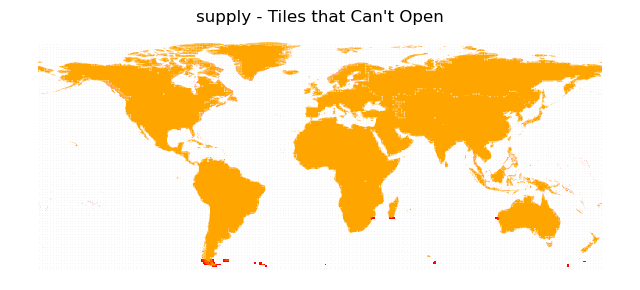

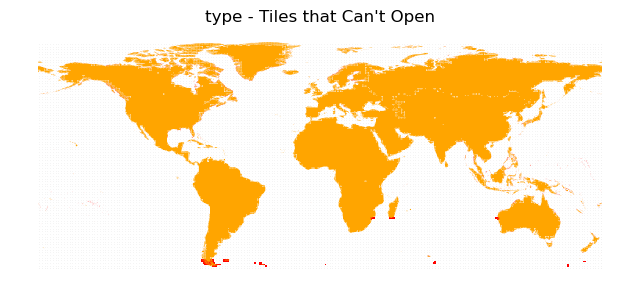

In [ ]:
for product in df_report["product"].unique():
    tiles = df_report.loc[
        (df_report["product"] == product) &
        (df_report["cant_open_raster"] == True),
        "tile_number"
    ].unique()

    gdf_subset = gdf_1d_grid[gdf_1d_grid["tile_index"].isin(tiles)]

    ax = gdf_1d_grid.plot(color="lightgrey", edgecolor="white", figsize=(8, 8))
    gdf_subset.plot(ax=ax, color="red")
    gdf_gadm.plot(ax=ax, color="orange", label="gadm base layer")

    ax.set_title(f"{product} - Tiles that can't be open")
    ax.set_axis_off()

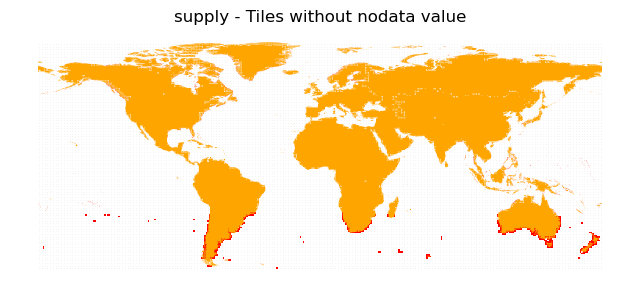

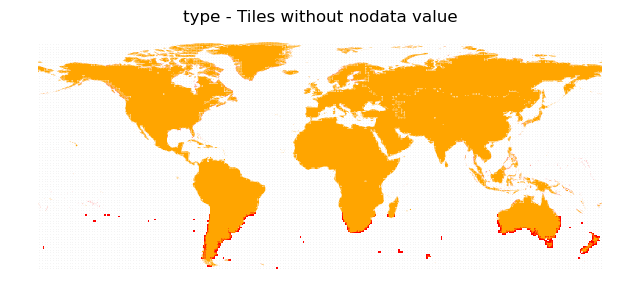

In [24]:
for product in df_report["product"].unique():
    tiles = df_report.loc[
        (df_report["product"] == product) &
        (df_report["nodata_value_not_set"] == True),
        "tile_number"
    ].unique()

    gdf_subset = gdf_1d_grid[gdf_1d_grid["tile_index"].isin(tiles)]

    ax = gdf_1d_grid.plot(color="lightgrey", edgecolor="white", figsize=(8, 8))
    gdf_subset.plot(ax=ax, color="red")
    gdf_gadm.plot(ax=ax, color="orange", label="gadm base layer")

    ax.set_title(f"{product} - Tiles without nodata value")
    ax.set_axis_off()

In [ ]:
"""OPTION 1: Extract all the used layers from geoserver"""
base_url = "https://integratedmodelling.org/geoserver/ows"
coverage_id = "im-data-global-conservation__global_tropical_moist_forest_transition_Subtyp_30m_v1_1982_2024"
version = "2.0.1"

# take the layer name as an output
output_file = rf".\{coverage_id.split('__', 1)[1]}.tif"

# Get the properties of the layer
properties = wcs_describe_coverage_bbox(base_url, coverage_id, version)

ymin, xmin, ymax, xmax, width, height, *_ = properties # *_ ignore the rest

# Get the layer
file_path = wcs_getcoverage(base_url, coverage_id, properties, output_file, version, simple_coverage=True)

https://integratedmodelling.org/geoserver/ows?service=WCS&version=2.0.1&request=DescribeCoverage&CoverageId=im-data-global-conservation__global_tropical_moist_forest_transition_Subtyp_30m_v1_1982_2024


## Nodata check: Option 1

In [ ]:
"""Simple checking"""

results = []
for tif_path in files_list:
    file = os.path.basename(tif_path)

    empty_percentage, is_half_empty = check_raster_emptyness(tif_path)

    results.append({
        # "tile": extract_tile_number(file, start_filter, end_filter),
        "file": file,
        "path": tif_path,
        "empty_percentage": round(empty_percentage, 2) if empty_percentage is not None else None,
        "half_or_more_empty": is_half_empty
    })

df_nodata_report = pd.DataFrame(results)



# Get all the more than half empty records
df_half_empty = df_nodata_report[df_nodata_report["half_or_more_empty"] == True] # To avoid nans
print(df_report.head())

# Export the results
if df_half_empty:
    df_half_empty.to_csv("failed_tiles.csv")
df_report.to_csv("dataframe_report.csv")

⚠ Cannot open raster: gbf.aries.grazed_biomass.potential_natural_vegetation_supply_for_grazing_22988.000000000000000_100.m_2020.tiff
⚠ Cannot open raster: gbf.aries.grazed_biomass.potential_natural_vegetation_supply_for_grazing_13442.000000000000000_100.m_2020.tiff
⚠ Cannot open raster: gbf.aries.grazed_biomass.potential_natural_vegetation_supply_for_grazing_12715.000000000000000_100.m_2020.tiff
⚠ Cannot open raster: gbf.aries.grazed_biomass.grassland_type_13431.000000000000000_100.m_2020.tiff
⚠ Cannot open raster: gbf.aries.grazed_biomass.potential_natural_vegetation_supply_for_grazing_13069.000000000000000_100.m_2020.tiff
⚠ Cannot open raster: gbf.aries.grazed_biomass.grassland_type_13786.000000000000000_100.m_2020.tiff
⚠ Cannot open raster: gbf.aries.grazed_biomass.grassland_type_13670.000000000000000_100.m_2020.tiff
⚠ Cannot open raster: gbf.aries.grazed_biomass.grassland_type_24085.000000000000000_100.m_2020.tiff
⚠ Cannot open raster: gbf.aries.grazed_biomass.grassland_type_12353.

ValueError: Cannot mask with non-boolean array containing NA / NaN values

In [30]:
df_half_empty = df_nodata_report[df_nodata_report["half_or_more_empty"] == True]

NameError: name 'df_nodata_report' is not defined

## Option 2

In [ ]:
"""Get the layers from geoserver"""
geoserver_layer_1 = {
"base_url": "https://integratedmodelling.org/geoserver/ows",
"coverage_id": "im-data-global-conservation__global_tropical_moist_forest_transition_Subtyp_30m_v1_1982_2024",
"version": "2.0.1"}

geoserver_layer_2 = {
"base_url": "https://integration.integratedmodelling.org/geoserver/ows",
"coverage_id": "im-data-global-ecology__global_jrc_ipcc_climate_zones_epsg4326_10km_2010",
"version": "2.0.1"}

geoserver_layers_list = [geoserver_layer_1, geoserver_layer_2]

In [ ]:
"""Advanced cheking"""

tmp_folder = ".\temp_folder"
if not os.path.exists(tmp_folder):
    os.mkdir(tmp_folder)

results = []
for raster_path in files_list:
    # Open the raster and get its properties
    with rasterio.open(raster_path) as src:
        src_array = src.read(1)
        # Raster dimensions
        width = src.width
        height = src.height
        # Bounding box
        xmin, ymin, xmax, ymax = src.bounds

        """Version 2.0.1 Geoserver additional params"""
        #axis_labels
        axis_labels = ['Lat', 'Long']

        # second_axis_labels 
        second_axis_labels = ["i", "j"]

    # put everything in a single set
    properties = (ymin, xmin, ymax, xmax, width, height, axis_labels, second_axis_labels)

    # Convert rastes to a boolean presence mask
    src_mask = src_array != 0

    """Extract the tiles corresponding to that layer"""
    input_paths = []
    for geoserver_layer in geoserver_layers_list:
        
        # Get the properties one by one
        base_url, coverage_id, version = (
            geoserver_layer["base_url"],
            geoserver_layer["coverage_id"],
            geoserver_layer["version"],
        )

        # Create the output layer name as an output with the bbox
        output_file = os.path.join(tmp_folder, coverage_id.split('__', 1)[1] + f"_{ymin}_{xmin}_{ymax}_{xmax}.tif")

        # Get the layer
        file_path = wcs_getcoverage(base_url, coverage_id, properties, output_file, version, simple_coverage=False)
        input_paths.append(file_path)
    
    """Convert GeoServer layers to boolean masks"""
    masks = []
    for input_path in input_paths:
        with rasterio.open(input_path) as src:
            data = src.read(1) # Read the first band
            mask = data != 0 # Convert to boolean:
            masks.append(mask)

    """Combine all masks pixel-by-pixel"""
    # Result is True only where *all* layers are True
    combined_mask = np.logical_and.reduce(masks)

    """Pixel presence similarity (Jaccard / IoU)"""
     # Intersection: pixels present in both
    intersection = np.logical_and(src_mask, combined_mask).sum()
    # Union: pixels present in at least one
    union = np.logical_or(src_mask, combined_mask).sum()

    # Similarity as percentage
    similarity_percentage = (
        (intersection / union) * 100 if union > 0 else 100.0
    )

    """Empty pixel analysis"""
    total_pixels = combined_mask.size
    empty_pixels = np.logical_not(combined_mask).sum()

    empty_percentage = (empty_pixels / total_pixels) * 100
    is_half_empty = empty_percentage >= 50

    """Store results"""

    file = os.path.basename(raster_path)

    results.append({
        "tile": extract_tile_number(file),
        "file": file,
        "path": raster_path,
        "similarity_percentage": round(similarity_percentage, 2),
        "empty_percentage": round(empty_percentage, 2),
        "half_or_more_empty": is_half_empty
    })
# Convert to DataFrame
df_similarity = pd.DataFrame(results)

## Option 3